In [19]:
import sys
from pathlib import Path

# Add the src directory to Python path
sys.path.insert(0, str(Path().resolve().parent / 'src'))

from config import EXTERNAL_DATA_DIR, INTERIM_DATA_DIR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [20]:
# Load the market metadata
metadata_file = INTERIM_DATA_DIR / 'musk_polymarket_outcomes_metadata.parquet'
df = pd.read_parquet(metadata_file)

print(f"Loaded {len(df)} market outcomes")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample questions:")
print(df['question'].head(10).tolist())

Loaded 1519 market outcomes
Shape: (1519, 20)

Columns: ['parent_slug', 'market_id', 'question', 'condition_id', 'slug', 'end_date', 'closed', 'active', 'volume', 'volume_num', 'clob_token_id', 'outcome_prices', 'last_trade_price', 'best_bid', 'best_ask', 'group_item_title', 'created_at', 'updated_at', 'closed_time', 'uma_resolution_status']

Sample questions:
['Will Elon tweet less than 40 times?', 'Will Elon tweet between 40 and 49 times?', 'Will Elon tweet between 50 and 59 times?', 'Will Elon tweet between 60 and 69 times?', 'Will Elon tweet between 70 and 79 times?', 'Will Elon tweet between 80 and 89 times?', 'Will Elon tweet between 90 and 99 times?', 'Will Elon tweet 100 or more times?', 'Will Elon post less than 40 times?', 'Will Elon post 40-49 times?']


In [21]:
# Function to parse tweet count range from question
def parse_tweet_range(question):
    """
    Extract tweet count range from question text.
    Returns (min, max) tuple or None if can't parse.
    """
    if not question or not isinstance(question, str):
        return None
    
    question = question.lower()
    
    # Pattern: "less than X" or "fewer than X"
    match = re.search(r'(?:less|fewer) than (\d+)', question)
    if match:
        return (0, int(match.group(1)) - 1)
    
    # Pattern: "X or more" or "X or greater"
    match = re.search(r'(\d+) or (?:more|greater)', question)
    if match:
        return (int(match.group(1)), int(match.group(1)) + 50)  # Upper bound estimate
    
    # Pattern: "X-Y" or "between X and Y"
    match = re.search(r'(\d+)[-–](\d+)', question)
    if match:
        return (int(match.group(1)), int(match.group(2)))
    
    match = re.search(r'between (\d+) and (\d+)', question)
    if match:
        return (int(match.group(1)), int(match.group(2)))
    
    return None

# Test the function
test_questions = [
    "Will Elon tweet less than 40 times?",
    "Will Elon tweet between 40 and 49 times?",
    "Will Elon tweet 100 or more times?",
    "Will Elon post 50-59 times?"
]

print("Testing range parser:")
for q in test_questions:
    result = parse_tweet_range(q)
    if result:
        print(f"  '{q}' -> Range: {result[0]}-{result[1]}, Mean: {np.mean(result)}")
    else:
        print(f"  '{q}' -> Could not parse")

Testing range parser:
  'Will Elon tweet less than 40 times?' -> Range: 0-39, Mean: 19.5
  'Will Elon tweet between 40 and 49 times?' -> Range: 40-49, Mean: 44.5
  'Will Elon tweet 100 or more times?' -> Range: 100-150, Mean: 125.0
  'Will Elon post 50-59 times?' -> Range: 50-59, Mean: 54.5


In [22]:
# Parse ranges for all outcomes
def safe_get_range_min(q):
    result = parse_tweet_range(q)
    return result[0] if result is not None else None

def safe_get_range_max(q):
    result = parse_tweet_range(q)
    return result[1] if result is not None else None

df['range_min'] = df['question'].apply(safe_get_range_min)
df['range_max'] = df['question'].apply(safe_get_range_max)
df['range_mean'] = df[['range_min', 'range_max']].mean(axis=1)

print(f"Successfully parsed {df['range_mean'].notna().sum()} out of {len(df)} ranges")
print(f"\nSample parsed data:")
print(df[['question', 'range_min', 'range_max', 'range_mean']].head(10))

Successfully parsed 1493 out of 1519 ranges

Sample parsed data:
                                   question  range_min  range_max  range_mean
0       Will Elon tweet less than 40 times?        0.0       39.0        19.5
1  Will Elon tweet between 40 and 49 times?       40.0       49.0        44.5
2  Will Elon tweet between 50 and 59 times?       50.0       59.0        54.5
3  Will Elon tweet between 60 and 69 times?       60.0       69.0        64.5
4  Will Elon tweet between 70 and 79 times?       70.0       79.0        74.5
5  Will Elon tweet between 80 and 89 times?       80.0       89.0        84.5
6  Will Elon tweet between 90 and 99 times?       90.0       99.0        94.5
7        Will Elon tweet 100 or more times?      100.0      150.0       125.0
8        Will Elon post less than 40 times?        0.0       39.0        19.5
9               Will Elon post 40-49 times?       40.0       49.0        44.5


In [23]:
# Parse outcome prices to get market probabilities
def parse_outcome_price(outcome_prices):
    """
    Parse outcome prices JSON string to get the 'Yes' probability.
    """
    # Handle None
    if outcome_prices is None:
        return None
    
    # Check if it's a scalar NaN using try/except
    try:
        if pd.isna(outcome_prices) and not hasattr(outcome_prices, '__iter__'):
            return None
    except (TypeError, ValueError):
        # If pd.isna fails, it's likely array-like, continue
        pass
    
    # If it's not a list or array-like, return None
    if not isinstance(outcome_prices, (list, tuple, np.ndarray)):
        return None
    
    # If it's empty, return None
    if len(outcome_prices) == 0:
        return None
    
    try:
        # outcome_prices is typically ["0.XX", "0.YY"] where first is Yes probability
        return float(outcome_prices[0])
    except (ValueError, TypeError, IndexError):
        return None

df['probability'] = df['outcome_prices'].apply(parse_outcome_price)

print(f"Successfully parsed {df['probability'].notna().sum()} probabilities")
print(f"\nSample with probabilities:")
print(df[['question', 'range_mean', 'probability']].head(10))

Successfully parsed 1519 probabilities

Sample with probabilities:
                                   question  range_mean  probability
0       Will Elon tweet less than 40 times?        19.5          0.0
1  Will Elon tweet between 40 and 49 times?        44.5          0.0
2  Will Elon tweet between 50 and 59 times?        54.5          0.0
3  Will Elon tweet between 60 and 69 times?        64.5          0.0
4  Will Elon tweet between 70 and 79 times?        74.5          0.0
5  Will Elon tweet between 80 and 89 times?        84.5          1.0
6  Will Elon tweet between 90 and 99 times?        94.5          0.0
7        Will Elon tweet 100 or more times?       125.0          0.0
8        Will Elon post less than 40 times?        19.5          0.0
9               Will Elon post 40-49 times?        44.5          0.0


In [24]:
# For each parent_slug (week), calculate weighted mean and confidence intervals
weekly_stats = []

for slug in df['parent_slug'].unique():
    week_data = df[df['parent_slug'] == slug].copy()
    
    # Filter to valid ranges and probabilities
    valid_data = week_data[
        week_data['range_mean'].notna() & 
        week_data['probability'].notna()
    ]
    
    if len(valid_data) == 0:
        continue
    
    # Skip if all probabilities are zero
    if valid_data['probability'].sum() == 0:
        continue
    
    # Get the end date from the first outcome
    end_date = valid_data['end_date'].iloc[0]
    
    # Calculate weighted mean using market probabilities
    weighted_mean = np.average(
        valid_data['range_mean'], 
        weights=valid_data['probability']
    )
    
    # Calculate confidence intervals using the ranges
    min_val = valid_data['range_min'].min()
    max_val = valid_data['range_max'].max()
    
    # Weighted percentiles for tighter bounds
    ranges = valid_data['range_mean'].values
    probs = valid_data['probability'].values
    
    # Sort by range mean
    sort_idx = np.argsort(ranges)
    ranges_sorted = ranges[sort_idx]
    probs_sorted = probs[sort_idx]
    
    # Cumulative probability
    cum_prob = np.cumsum(probs_sorted)
    cum_prob = cum_prob / cum_prob[-1]  # Normalize
    
    # Find 25th and 75th percentiles
    ci_lower = ranges_sorted[np.searchsorted(cum_prob, 0.25)]
    ci_upper = ranges_sorted[np.searchsorted(cum_prob, 0.75)]
    
    weekly_stats.append({
        'slug': slug,
        'end_date': end_date,
        'tweet_count_mean': weighted_mean,
        'tweet_count_min': min_val,
        'tweet_count_max': max_val,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'num_outcomes': len(valid_data)
    })

weekly_df = pd.DataFrame(weekly_stats)
weekly_df = weekly_df.sort_values('end_date')

# Remove rows with NaT dates
weekly_df = weekly_df[weekly_df['end_date'].notna()]

print(f"Processed {len(weekly_df)} weeks")
print(f"\nSample weekly statistics:")
print(weekly_df.head(10))

Processed 87 weeks

Sample weekly statistics:
                                             slug                  end_date  \
0   of-elon-musk-tweets-between-may-31-and-june-7 2024-06-07 12:00:00+00:00   
1                   of-elon-musk-tweets-june-7-14 2024-06-14 12:00:00+00:00   
3                  elon-musk-of-tweets-june-21-28 2024-06-28 12:00:00+00:00   
4              elon-musk-of-tweets-june-28-july-5 2024-07-05 12:00:00+00:00   
5              elon-musk-of-tweets-july-5-july-12 2024-07-12 12:00:00+00:00   
6                  elon-musk-of-tweets-july-19-26 2024-07-26 12:00:00+00:00   
7                  elon-musk-of-tweets-august-2-9 2024-08-09 12:00:00+00:00   
8                 elon-musk-of-tweets-august-9-16 2024-08-16 12:00:00+00:00   
9                elon-musk-of-tweets-august-16-23 2024-08-23 12:00:00+00:00   
10               elon-musk-of-tweets-august-23-30 2024-08-30 12:00:00+00:00   

    tweet_count_mean  tweet_count_min  tweet_count_max  ci_lower  ci_upper  \
0     

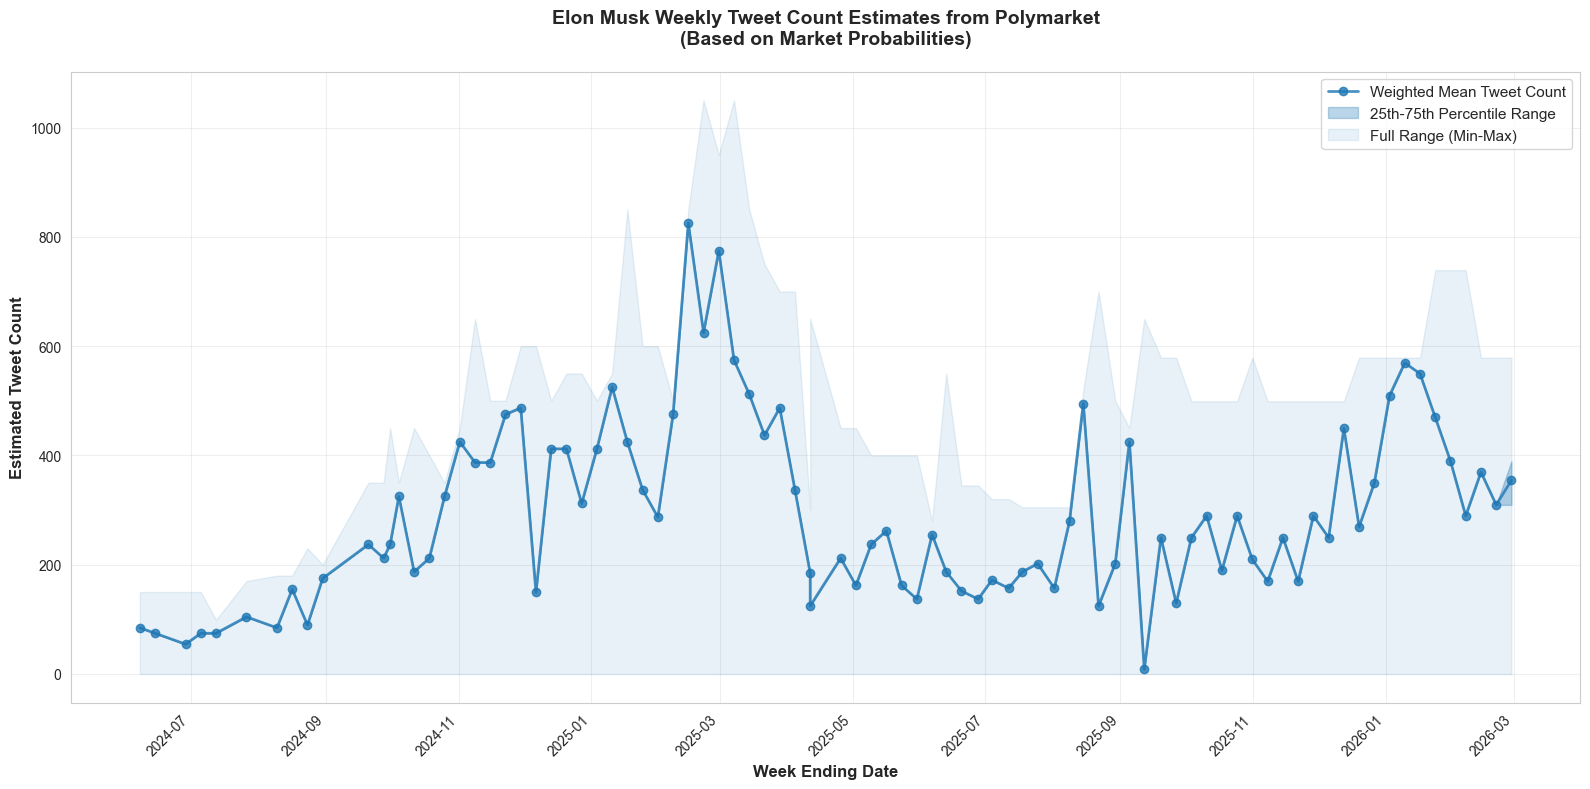


Summary Statistics:
  Mean weekly tweets: 292.2
  Std dev: 162.9
  Min: 8.5
  Max: 825.0


In [25]:
# Plot the tweet counts over time with confidence intervals
fig, ax = plt.subplots(figsize=(16, 8))

# Main line: weighted mean
ax.plot(weekly_df['end_date'], weekly_df['tweet_count_mean'], 
        'o-', linewidth=2, markersize=6, label='Weighted Mean Tweet Count', 
        color='#1f77b4', alpha=0.8)

# Confidence interval (25th-75th percentile)
ax.fill_between(weekly_df['end_date'], 
                weekly_df['ci_lower'], 
                weekly_df['ci_upper'],
                alpha=0.3, label='25th-75th Percentile Range', color='#1f77b4')

# Full range (min-max)
ax.fill_between(weekly_df['end_date'], 
                weekly_df['tweet_count_min'], 
                weekly_df['tweet_count_max'],
                alpha=0.1, label='Full Range (Min-Max)', color='#1f77b4')

ax.set_xlabel('Week Ending Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Estimated Tweet Count', fontsize=12, fontweight='bold')
ax.set_title('Elon Musk Weekly Tweet Count Estimates from Polymarket\n(Based on Market Probabilities)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\nSummary Statistics:")
print(f"  Mean weekly tweets: {weekly_df['tweet_count_mean'].mean():.1f}")
print(f"  Std dev: {weekly_df['tweet_count_mean'].std():.1f}")
print(f"  Min: {weekly_df['tweet_count_mean'].min():.1f}")
print(f"  Max: {weekly_df['tweet_count_mean'].max():.1f}")

Trend Analysis:
  Slope: 0.977 tweets/week
  R-squared: 0.023
  P-value: 0.1611
  Not significant trend


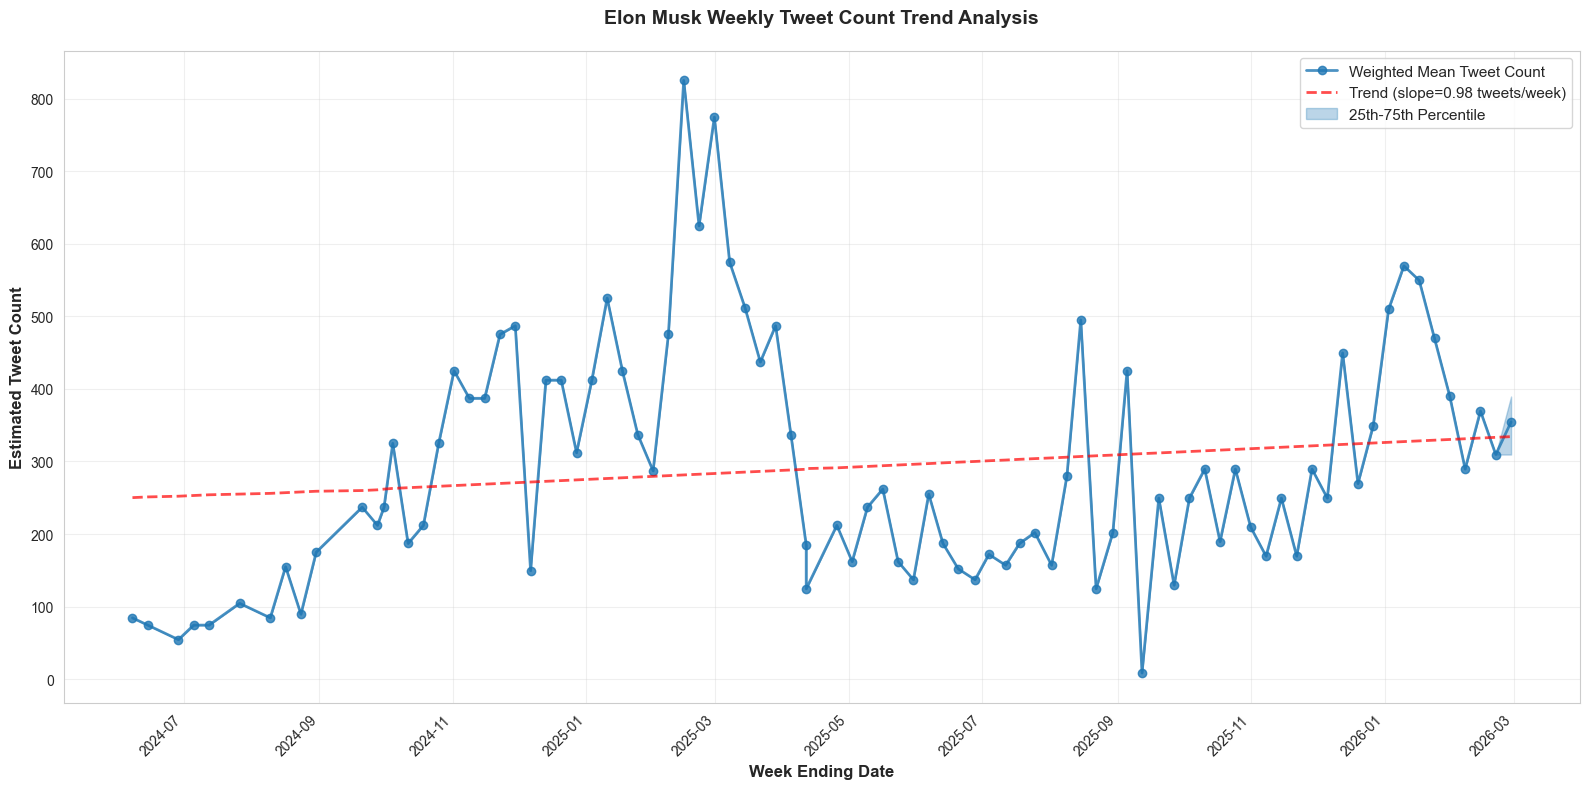

In [26]:
# Additional analysis: trend over time
from scipy.stats import linregress

# Create numeric time index for regression
weekly_df['time_idx'] = range(len(weekly_df))

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(
    weekly_df['time_idx'], 
    weekly_df['tweet_count_mean']
)

print(f"Trend Analysis:")
print(f"  Slope: {slope:.3f} tweets/week")
print(f"  R-squared: {r_value**2:.3f}")
print(f"  P-value: {p_value:.4f}")
print(f"  {'Significant' if p_value < 0.05 else 'Not significant'} trend")

# Plot with trend line
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(weekly_df['end_date'], weekly_df['tweet_count_mean'], 
        'o-', linewidth=2, markersize=6, label='Weighted Mean Tweet Count', 
        color='#1f77b4', alpha=0.8)

# Add trend line
trend_line = slope * weekly_df['time_idx'] + intercept
ax.plot(weekly_df['end_date'], trend_line, '--', 
        linewidth=2, label=f'Trend (slope={slope:.2f} tweets/week)', 
        color='red', alpha=0.7)

ax.fill_between(weekly_df['end_date'], 
                weekly_df['ci_lower'], 
                weekly_df['ci_upper'],
                alpha=0.3, label='25th-75th Percentile', color='#1f77b4')

ax.set_xlabel('Week Ending Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Estimated Tweet Count', fontsize=12, fontweight='bold')
ax.set_title('Elon Musk Weekly Tweet Count Trend Analysis', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
# Save the weekly statistics
output_file = INTERIM_DATA_DIR / 'musk_weekly_tweet_estimates.parquet'
weekly_df.to_parquet(output_file, index=False)

print(f"Saved weekly estimates to: {output_file}")
print(f"Shape: {weekly_df.shape}")
print(f"\nColumns: {weekly_df.columns.tolist()}")

Saved weekly estimates to: /Users/vince/Developer/indian_pizza_machine/backend/data/interim/musk_weekly_tweet_estimates.parquet
Shape: (87, 9)

Columns: ['slug', 'end_date', 'tweet_count_mean', 'tweet_count_min', 'tweet_count_max', 'ci_lower', 'ci_upper', 'num_outcomes', 'time_idx']
